# <u>***Иследовательский анализ рынка заведений общественного питания Москвы***</u>

- Автор: Якунин Михаил Евгеньевич
- Дата: 24 февраля 2026 г.

## *Цели и задачи проекта*

<u>**Цель исследования:**</u>

Провести комплексный анализ рынка заведений общественного питания Москвы для определения наиболее перспективных форматов, локаций и ценовых сегментов, которые обеспечат успешный старт нового проекта инвесторов фонда Shut Up and Take My Money.

<u>**Задачи проекта:**</u>

Для достижения поставленной цели необходимо последовательно решить следующие задачи:

*Первичный анализ данных:*

- Загрузить данные о заведениях Москвы и изучить их структуру.

- Оценить полноту данных, выявить явные пропуски и аномалии.

*Предобработка и подготовка данных:*

- Привести данные к единому формату, удобному для анализа.

- Обработать пропуски (если они не несут полезной информации) или скорректировать типы данных.

- При необходимости сгенерировать новые признаки (например, вычленить название улицы из полного адреса или отфильтровать сетевые/несетевые заведения).

*Исследование структуры рынка:*

- Определить соотношение различных категорий заведений (кафе, рестораны, бары, столовые и т.д.).

- Выявить преобладающие форматы и их долю на рынке.

*Анализ сетевых и несетевых заведений:*

- Оценить распространенность сетевого бизнеса.

- Выяснить, какие форматы чаще всего работают в сетевом формате, а какие остаются «единичными».

*Анализ территориального размещения:*

- Изучить распределение заведений по административным округам и районам Москвы.

- Выявить локации с наибольшей и наименьшей концентрацией заведений.

- Проанализировать, как меняется формат заведений в зависимости от удаленности от центра.

*Анализ ценовых характеристик:*

- Изучить распределение среднего чека по различным категориям заведений.

- Выявить зависимость ценового сегмента от района расположения.

*Анализ посадочных мест:*

- Оценить среднюю вместимость заведений разного типа.

- Выявить тренды в количестве посадочных мест для разных районов и ценовых сегментов.

*Формулировка рекомендаций:*

- На основе проведенного анализа выделить ниши с низкой конкуренцией и высоким потенциалом.

- Дать рекомендации по выбору оптимального типа заведения, локации и уровня цен для успешного старта.

## *Описание данных*

Файл `rest_info.csv` содержит информацию о заведениях общественного питания:
- id - индификатор заведения;
- name — название заведения;
- address — адрес заведения;
- district — административный район, в котором находится заведение, например Центральный административный округ;
- category — категория заведения, например «кафе», «пиццерия» или «кофейня»;
- hours — информация о днях и часах работы;
- rating — рейтинг заведения по оценкам пользователей в Яндекс Картах (высшая оценка — 5.0);
- chain — число, выраженное 0 или 1, которое показывает, является ли заведение сетевым (для маленьких сетей могут встречаться ошибки):
    - 0 — заведение не является сетевым;
    - 1 — заведение является сетевым.
- seats — количество посадочных мест.

Файл `rest_price.csv` содержит информацию о среднем чеке в заведениях общественного питания:
- id - индификатор заведения;
- price — категория цен в заведении, например «средние», «ниже среднего», «выше среднего» и так далее;
- avg_bill — строка, которая хранит среднюю стоимость заказа в виде диапазона, например:
    - «Средний счёт: 1000–1500 ₽»;
    - «Цена чашки капучино: 130–220 ₽»;
    - «Цена бокала пива: 400–600 ₽».
и так далее;
- middle_avg_bill — число с оценкой среднего чека, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Средний счёт»:
    - Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
    - Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
    - Если значения нет или оно не начинается с подстроки «Средний счёт», то в столбец ничего не войдёт.
- middle_coffee_cup — число с оценкой одной чашки капучино, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Цена одной чашки капучино»:
    - Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
    - Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
    - Если значения нет или оно не начинается с подстроки «Цена одной чашки капучино», то в столбец ничего не войдёт.

## *Содержание*

1. [Загрузка данных и знакомство с ними](#1)
2. [Предобработка данных](#2)
3. [Исследовательский анализ данных](#3)
4. [Итоговый вывод и рекомендации](#4)

## 1. Загрузка данных и знакомство с ними <a id=1></a>

### 1.1 *Загрузка данных*

In [1]:
# Импортируем библиотеки
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from phik import phik_matrix

In [2]:
# Загружаем данные
info_df = pd.read_csv('https://code.s3.yandex.net/datasets/rest_info.csv')
price_df = pd.read_csv('https://code.s3.yandex.net/datasets/rest_price.csv')

In [3]:
# Выводим первые 5 строк датафрейма info_df
info_df.head()

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


In [4]:
# Выведем информацию о датиафрейме info_df
info_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   str    
 1   name      8406 non-null   str    
 2   category  8406 non-null   str    
 3   address   8406 non-null   str    
 4   district  8406 non-null   str    
 5   hours     7870 non-null   str    
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), str(6)
memory usage: 591.2 KB


In [5]:
# Выводим первые 5 строк датафрейма price_df
price_df.head()

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


In [6]:
# Выведем информацию о датиафрейме price_df
price_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   str    
 1   price              3315 non-null   str    
 2   avg_bill           3816 non-null   str    
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), str(3)
memory usage: 158.6 KB


### 1.2 *Подготовка единого датафрейма*

In [7]:
# Объяденяем два датафрейма `info_df` и `price_df`
df = info_df.merge(price_df, how='left', on='id')

In [8]:
# Выводим информацию об объядененом датафрейме df
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   str    
 1   name               8406 non-null   str    
 2   category           8406 non-null   str    
 3   address            8406 non-null   str    
 4   district           8406 non-null   str    
 5   hours              7870 non-null   str    
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   str    
 10  avg_bill           3816 non-null   str    
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), str(8)
memory usage: 853.9 KB


### 1.3 *Промежуточный вывод*

<u>**Анализ входных датасетов**</u>

**Анализ датасета `rest_info.csv`**

Структура данных:
- Датасет содержит 8406 записей о заведениях общественного питания Москвы.
- Включает 9 столбцов с информацией об идентификаторах, названиях, адресах, округах, категориях, часах работы, рейтингах, принадлежности к сетям и количестве посадочных мест.

| Столбец | Текущий тип | Соответствие содержимому | Необходимость приведения |
| :--- | :--- | :--- | :--- |
| id | `object` | ✅ Соответствует, уникальные идентификаторы в виде хеш-строк | Не требуется |
| name | `object` | ✅ Соответствует, названия заведений | Не требуется |
| category | `object` | ⚠️ Частично соответствует, содержит наименование категории заведения | Можно преобразовать в категориальный |
| address | `object` | ✅ Соответствует, полные адреса | Не требуется |
| district | `object` | ⚠️ Частично соответствует, содержит информацию о районе в котором находиться объект | Можно преобразовать в категориальный |
| hours | `object` | ⚠️ Частично соответствует, содержит текстовое описание режима работы. Требуется извлечение дней и часов | Требуется обработка для анализа |
| rating | `float64` | ✅ Соответствует, числовые значения рейтинга от 0 до 5 | Не требуется |
| chain | `int64` | ✅ Соответствует, бинарный признак (0/1) | Можно преобразовать в категориальный |
| seats | `float64` | ⚠️ Не соответствует, количество поситителей является целочисленным числом, можно привести к типу `int` | Привести к типу `int16` |

**Анализ датасета `rest_price.csv`**

Структура данных:
- Датасет содержит 4058 записей о ценовых характеристиках заведений.
- Включает 5 столбцов: идентификатор, категория цены, описание среднего чека, числовое значение среднего чека, числовое значение цены капучино.

| Столбец | Текущий тип | Соответствие содержимому | Необходимость приведения |
| :--- | :--- | :--- | :--- |
| id | `object` | ✅ Соответствует, уникальные идентификаторы | Не требуется |
| price | `object` | ⚠️ Частично соответствует, категориальные значения ("средние", "выше среднего" и т.д.) | Можно преобразовать в упорядоченный категориальный тип |
| avg_bill | `object` | ✅ Соответствует, текстовое описание чека | Требуется парсинг для извлечения числовых значений |
| middle_avg_bill | `float64` | ✅ Соответствует, числовые значения медианы чека | Не требуется, но есть пропуски |
| middle_coffee_cup | `float64` | ✅ Соответствует, числовые значения цены кофе | Не требуется, но есть пропуски |

**Проблемы и особенности:**

- Неполнота данных: Датасет содержит информацию только для 4058 заведений из 8406, что составляет ~48% от общего количества.

- Пропуски в категории цены: Столбец price отсутствует для 743 записей (~18% от датасета).

- Специфичность данных:

    - middle_avg_bill заполнен только для заведений с формулировкой "Средний счёт" (3149 записей, ~78% от датасета).

    - middle_coffee_cup заполнен только для заведений с формулировкой "Цена чашки капучино" (535 записей, ~13% от датасета), что характерно преимущественно для кофеен.

- Сложность парсинга: Столбец avg_bill содержит разнородные форматы описания цен (диапазоны, значения "от", конкретные числа), что потребует дополнительной обработки.

<u>**Анализ объединеного датафрейма**</u>

**Структура данных:**

- После объединения через левое соединение (how='left') получен датафрейм с 8406 записями и 13 столбцами.

- Для заведений, отсутствующих в price_df, соответствующие ценовые показатели содержат пропуски.

- Ключевые проблемы, требующие решения на этапе предобработки:

**Критические пропуски:**

- seats - 43% пропусков - требует решения (возможно, заполнение медианными значениями по категориям или удаление записей)

- price - 60% пропусков - требует категоризации отсутствующих данных

- middle_avg_bill - 63% пропусков - ограничивает анализ среднего чека

- middle_coffee_cup - 94% пропусков - применим только для узкого сегмента заведений

**Требуется преобразование типов:**

- chain - преобразовать в категориальный тип для более эффективного анализа

- price - преобразовать в упорядоченный категориальный тип для анализа ценовых сегментов

- category и district - рассмотреть возможность преобразования в категориальный тип

**Требуется генерация новых признаков:**

- Извлечение улицы из address для географического анализа

- Парсинг hours для выделения режима работы (круглосуточно, выходные и т.д.)

- Парсинг avg_bill для получения унифицированных числовых значений чека

- Создание признака "только кофейня" на основе наличия middle_coffee_cup

<u>**Общее заключение**</u>

Данные загружены, структура изучена, выявлены основные проблемы качества данных. Несмотря на значительное количество пропусков в ценовых показателях и посадочных местах, общий объем данных достаточен для проведения репрезентативного анализа рынка. На следующем этапе предстоит выполнить очистку данных, преобразование типов и генерацию новых признаков, что позволит перейти к полноценному исследовательскому анализу рынка заведений общественного питания Москвы.

## 2. Предобработка данных <a id=2></a>

### 2.1 Поиск пропусков и замена типов данных

In [9]:
# Выведим количество всех пропусков в датафрейме
df.isna().sum()

id                      0
name                    0
category                0
address                 0
district                0
hours                 536
rating                  0
chain                   0
seats                3611
price                5091
avg_bill             4590
middle_avg_bill      5257
middle_coffee_cup    7871
dtype: int64

In [10]:
# Выводим относительное количество пропусков в процентах %
round(df.isna().mean()*100, 2)

id                    0.00
name                  0.00
category              0.00
address               0.00
district              0.00
hours                 6.38
rating                0.00
chain                 0.00
seats                42.96
price                60.56
avg_bill             54.60
middle_avg_bill      62.54
middle_coffee_cup    93.64
dtype: float64

Для преобразования тип данных столбца `seats` необходимо избавиться от пропусков. Так как пропуски составляют `43%`, это значемая часть данных, то мы их удалить не можем. Для удобста последующего преобразования, заменим пусые ячейки значением индекатором. В даном случае используем значение `-1`, так количество посадочных мест не может быть отрецательным

In [11]:
# Заменяем пустые ячейки на -1 и меняем тип данных на int16
df['seats'] = df['seats'].fillna(-1).astype('int16')

In [12]:
# Меняем тип данных у столбца chain на тип данных ште8
df['chain'] = df['chain'].astype('int8')

Для столбца `hours` имеется пропуски которы составляют чуть больше `6%`. Этот объем данных не является статестически важным, поэтому мы можем строки с пустыми данными удалить.

In [13]:
# Удалим строки с пустыми ячейками в столбце hours
df = df.dropna(subset='hours')

In [14]:
# Выводим информацию об обновленном датафрейме
df.info()

<class 'pandas.DataFrame'>
Index: 7870 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 7870 non-null   str    
 1   name               7870 non-null   str    
 2   category           7870 non-null   str    
 3   address            7870 non-null   str    
 4   district           7870 non-null   str    
 5   hours              7870 non-null   str    
 6   rating             7870 non-null   float64
 7   chain              7870 non-null   int8   
 8   seats              7870 non-null   int16  
 9   price              3310 non-null   str    
 10  avg_bill           3808 non-null   str    
 11  middle_avg_bill    3143 non-null   float64
 12  middle_coffee_cup  534 non-null    float64
dtypes: float64(3), int16(1), int8(1), str(8)
memory usage: 760.9 KB


### 2.2 Проверим датафрейм на явные и не явные дубликаты

In [15]:
# Проведем нормлизацию текстовых столбцов


In [16]:
# Проверим датафрейм на явные дубликаты
df.duplicated().sum()

np.int64(0)

In [17]:
# Проверим датафрейм на неявные дубликаты
df.duplicated(subset='id').sum()

np.int64(0)

In [18]:
# Выведем полную информацию по столбца о дубликатах

# Находим максимальную длину имени столбца и максимальное количество дубликатов
max_col_len = max(len(col) for col in df.columns)
max_duplicates_len = max(len(str(df[col].duplicated().sum())) for col in df.columns)

for column in df.columns:
    duplicates = df[column].duplicated().sum()
    print(f'В столбце {column:<{max_col_len}} найдено  {duplicates:>{max_duplicates_len}}  дубликатов')

В столбце id                найдено     0  дубликатов
В столбце name              найдено  2557  дубликатов
В столбце category          найдено  7862  дубликатов
В столбце address           найдено  2410  дубликатов
В столбце district          найдено  7861  дубликатов
В столбце hours             найдено  6563  дубликатов
В столбце rating            найдено  7830  дубликатов
В столбце chain             найдено  7868  дубликатов
В столбце seats             найдено  7643  дубликатов
В столбце price             найдено  7865  дубликатов
В столбце avg_bill          найдено  6974  дубликатов
В столбце middle_avg_bill   найдено  7639  дубликатов
В столбце middle_coffee_cup найдено  7773  дубликатов


Создаем столбец `is_24_7` с обозначением того, что заведение работает ежедневно и круглосуточно, то есть 24/7:
  - логическое значение `True` — если заведение работает ежедневно и круглосуточно;
  - логическое значение `False` — в противоположном случае.

In [19]:
# Создадим буливый столбец is_24_7
df['is_24_7'] = df['hours'].apply(lambda x: True if x == 'ежедневно, круглосуточно' else False)

In [20]:
# Вывидим 5 случайных строк датафрейма
df.sample(5)

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup,is_24_7
7890,cdd0b1a4c4174449b7286df4dfe14ab9,Моремания,ресторан,"Москва, Каширское шоссе, 80",Южный административный округ,"пн-чт 10:00–22:00; пт,сб 10:00–23:00; вс 10:00...",4.5,1,110,NaN,Средний счёт:2000–2500 ₽,2250.0,NaN,False
2392,c42746490e0b48f18c62c614aa00c595,Nho,ресторан,"Москва, 1-я Останкинская улица, 55",Северо-Восточный административный округ,"ежедневно, 10:00–22:00",3.8,0,30,NaN,NaN,NaN,NaN,False
3096,13b840a952c04559aa52e72b21494912,Донер,быстрое питание,"Москва, Осенний бульвар, 10",Западный административный округ,"ежедневно, круглосуточно",3.1,1,70,NaN,Средний счёт:130–200 ₽,165.0,NaN,True
437,dbab41c56e0a44f9a59c5fc031cd97b8,Буханка,булочная,"Москва, Левобережная улица, 4к10",Северный административный округ,"ежедневно, 07:00–22:00",4.3,1,-1,NaN,NaN,NaN,NaN,False
3354,248f551422c14f27924e688ea4c03f91,Golden coffee,кофейня,"Москва, Кутузовский проспект, 36, стр. 5",Западный административный округ,"ежедневно, 10:00–22:00",4.7,0,-1,NaN,NaN,NaN,NaN,False


### 2.3 Промежуточные выводы после предобработки

## 3. Исследовательский анализ данных <a id=3></a>

In [21]:
# Создадим функцию для создания столбчатых деаграмм
def creat_plot_bar(df, column, title, xlabel, ylabel, mean_value=True, rot=90):
    """
    Функция для построения столбчатой диаграммы распределения со средним значением
    
    Parameters:
    df: DataFrame
    column: str - название колонки для анализа
    title: str - заголовок графика
    xlabel: str - подпись оси X
    ylabel: str - подпись оси Y
    mean_value: bool - нужно ли отображать среднее значение
    rot: int - значение на сколько нужно повернуть указателей по оси Х
    """
    plt.figure(figsize=(10, 4))
    
    # Подсчет значений и построение графика
    value_counts = df[column].value_counts()
    value_counts.plot(
        kind='bar', 
        label='кол-во',
        rot=rot
    )
    
    # Расчет и добавление среднего
    if mean_value:
        plt.axhline(
            df[column].value_counts().mean(),
            color='red',
            linestyle='--',
            label=f'Среднее: {df[column].value_counts().mean():.2f}'
        )
    
    # Настройка графика
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True, alpha=0.7)
    
    plt.show()

### 3.1 Иследуем категории заведений

In [22]:
# Расчитаем количество заведений по каждой категории
df['category'].value_counts()


category
кафе               2003
ресторан           1969
кофейня            1398
бар,паб             747
пиццерия            628
быстрое питание     570
столовая            306
булочная            249
Name: count, dtype: int64

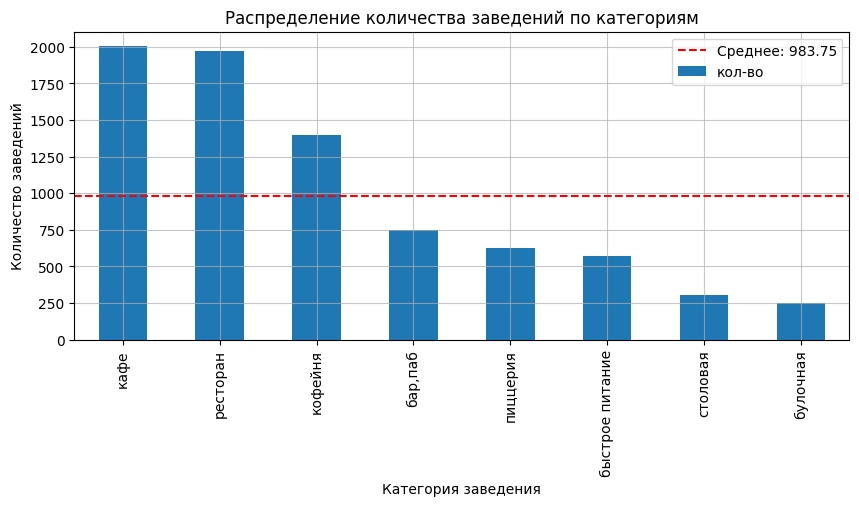

In [23]:
# Построим столбцатую диаграму
creat_plot_bar(
    df, 
    'category', 
    'Распределение количества заведений по категориям',
    'Категория заведения',
    'Количество заведений'
)

### 3.2 Иследуем распределение заведений по районам

In [24]:
# Расчитаем количество заведений в каждом районе
df['district'].value_counts()


district
Центральный административный округ         2211
Северный административный округ             846
Северо-Восточный административный округ     830
Южный административный округ                827
Западный административный округ             785
Восточный административный округ            723
Юго-Западный административный округ         650
Юго-Восточный административный округ        629
Северо-Западный административный округ      369
Name: count, dtype: int64

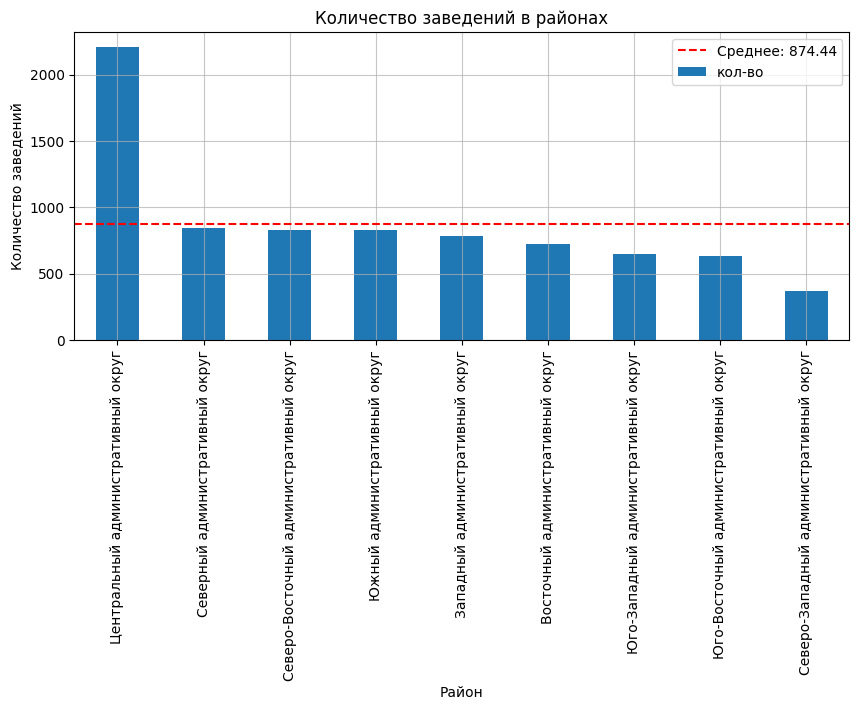

In [25]:
# Построим столбцатую диаграму
creat_plot_bar(
    df,
    'district',
    'Количество заведений в районах',
    'Район',
    'Количество заведений'
)

In [26]:
# Распределение заведений по категоиям в Центральном округе
df_cao_category = df[df['district']=='Центральный административный округ']
df_cao_category['category'].value_counts()

category
ресторан           665
кафе               444
кофейня            426
бар,паб            364
пиццерия           112
быстрое питание     85
столовая            65
булочная            50
Name: count, dtype: int64

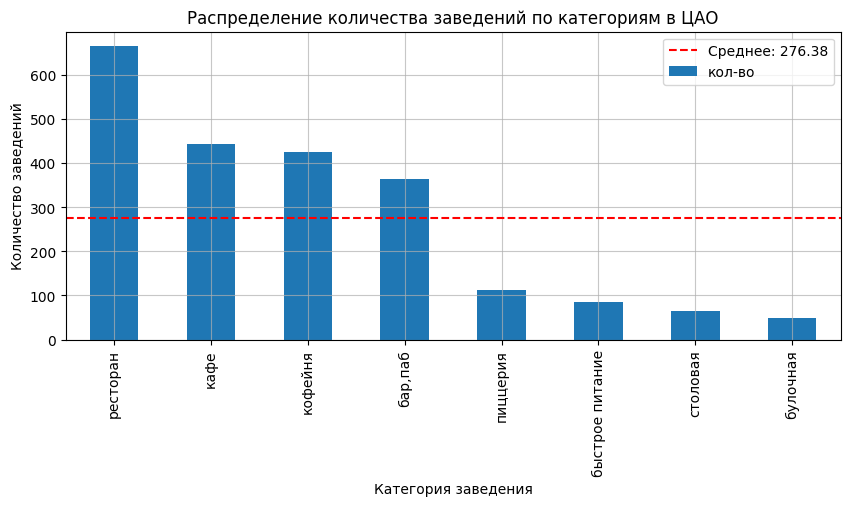

In [27]:
# Построим столбцатую диаграму
creat_plot_bar(
    df_cao_category,
    'category',
    'Распределение количества заведений по категориям в ЦАО',
    'Категория заведения',
    'Количество заведений'
)

### 3.3 Иследование сетевых и не сетевых заведений

In [28]:
# Расчитаем количество сетевых и не сетевых заведений
df['chain'].value_counts().rename(index={0: "сетевое заведение", 1: "не сетевое заведение"})

chain
сетевое заведение       4781
не сетевое заведение    3089
Name: count, dtype: int64

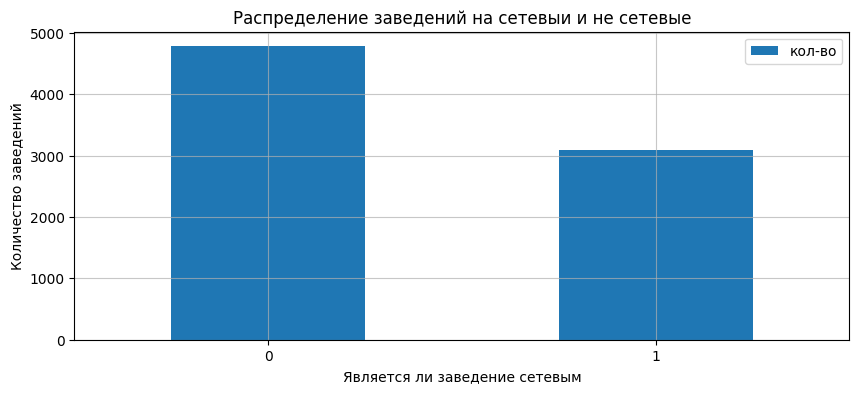

In [29]:
# Построим столбцатую диаграму
creat_plot_bar(
    df, 
    'chain',
    'Распределение заведений на сетевыи и не сетевые',
    'Является ли заведение сетевым',
    'Количество заведений',
    False,
    0
)

<Axes: title={'center': 'Распределение стевых заведений в зависимости от категории'}, xlabel='Категория заведения', ylabel='Количество заведений'>

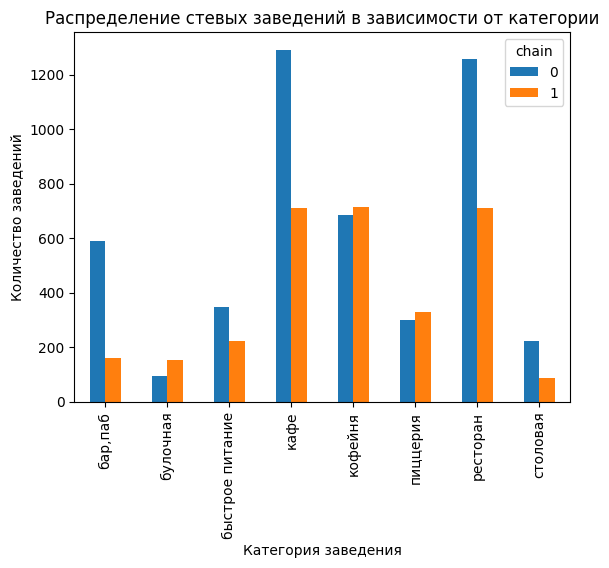

In [30]:
# Расчитаем распределение сетевых и не сетевых заведений в зависимости от категории
group_category = df.groupby('category')['chain'].value_counts().unstack(fill_value=0)
group_category.plot(
    kind='bar',
    title='Распределение стевых заведений в зависимости от категории',
    xlabel='Категория заведения',
    ylabel='Количество заведений'
)

### 3.4 Иследование посадочных мест заведений

<Axes: title={'center': 'Гистограма распределения посадочных мест'}, xlabel='Посадочные места', ylabel='Частота'>

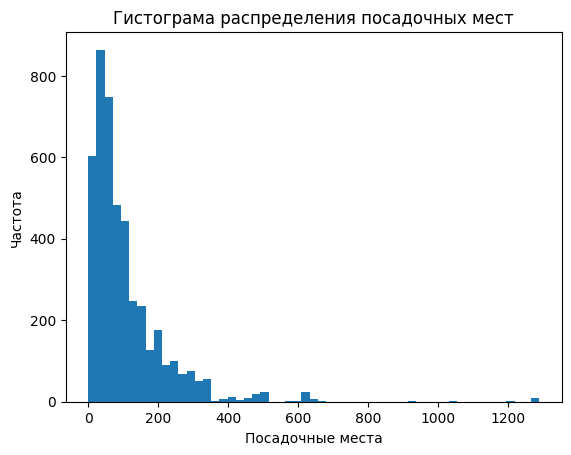

In [31]:
# Выводим гистограмму распределения посадочных мест
df_seats = df[df['seats'] >= 0]
df_seats['seats'].plot(
    kind='hist',
    bins=55,
    title='Гистограма распределения посадочных мест',
    xlabel='Посадочные места',
    ylabel='Частота', 
)

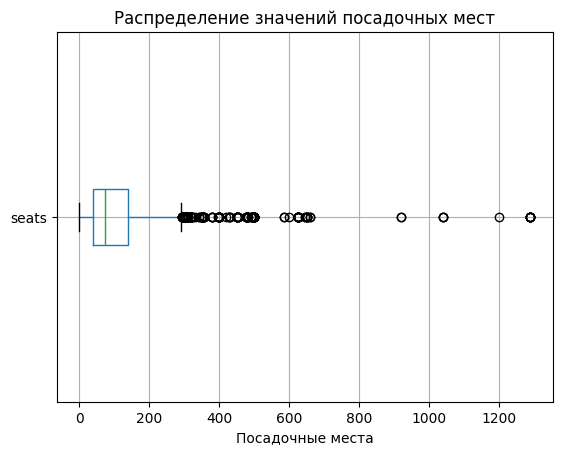

In [32]:
# Строим диаграмму размаха значений в столбце seats
df_seats.boxplot(
    column='seats', 
    vert=False
)

# Добавляем заголовок и метки оси
plt.title('Распределение значений посадочных мест')
plt.xlabel('Посадочные места')

# Выводим график
plt.show()

In [48]:
# Изучаем статистические показатели столбца seats
df_seats['seats'].describe().round(2)

count    4495.00
mean      107.85
std       119.20
min         0.00
25%        40.00
50%        75.00
75%       140.00
max      1288.00
Name: seats, dtype: float64

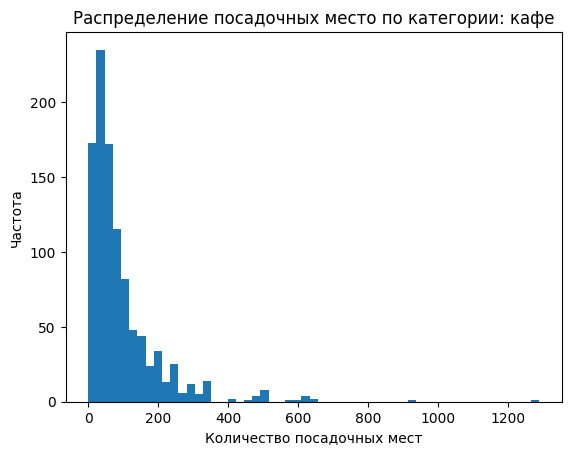

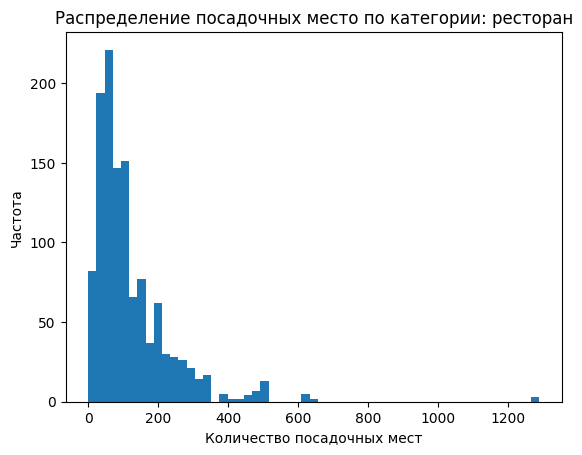

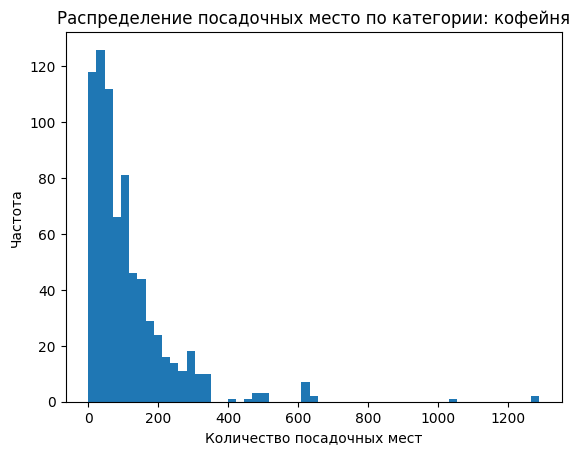

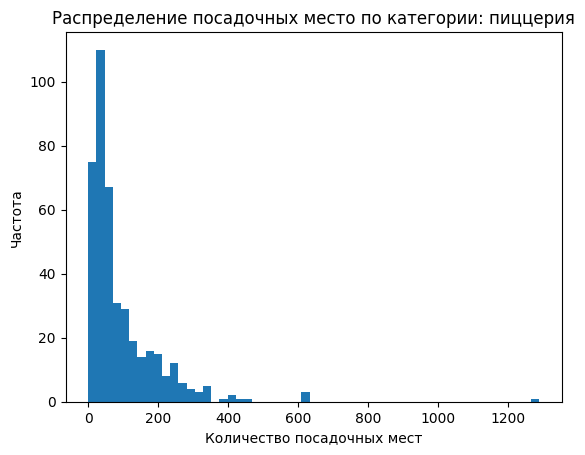

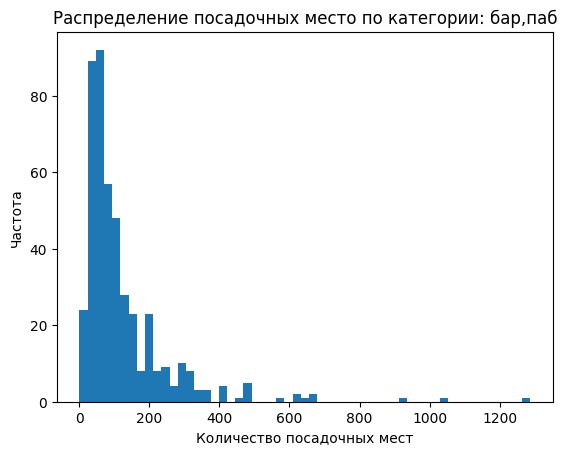

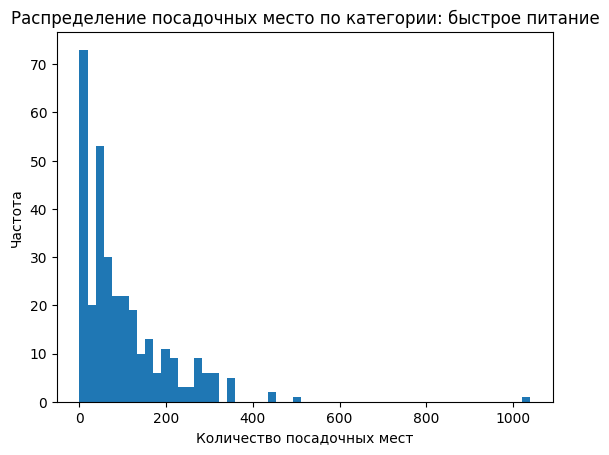

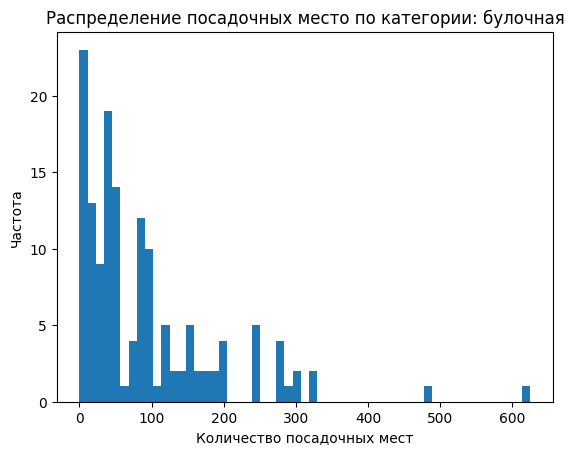

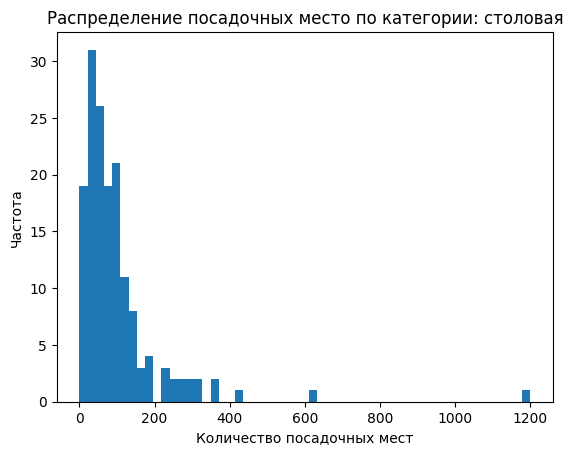

In [33]:
# Выводим гистограмму распределения посадочных мест в зависимости от категории заведения
for category in df['category'].unique():
    df_seats[df_seats['category'] == category]['seats'].plot(
        kind='hist',
        bins=55,
        title = f'Распределение посадочных место по категории: {category}',
        xlabel='Количество посадочных мест',
        ylabel='Частота'
    )

    plt.show()

In [34]:
# Расчитаем среднее количество посадочных мест для категорий заведений
df_category_seat = df.groupby('category')['seats'].mean().reset_index(name='среднее').round(2)
df_category_seat

,category,среднее
0,"бар,паб",74.01
1,булочная,52.39
2,быстрое питание,56.67
3,кафе,47.85
4,кофейня,59.04
5,пиццерия,63.41
6,ресторан,74.63
7,столовая,51.02


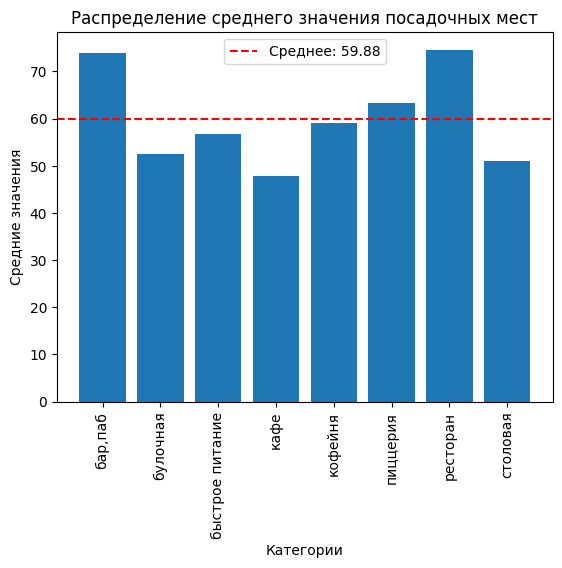

In [46]:
# Строим диаграмму среднего значения посадочных мест
plt.bar(df_category_seat['category'], df_category_seat['среднее'])

plt.axhline(
    df_category_seat['среднее'].mean(),
    color='red',
    linestyle='--',
    label=f'Среднее: {df_category_seat['среднее'].mean():.2f}'
)      

# Настраиваем оформление графика
plt.title('Распределение среднего значения посадочных мест')  
plt.xlabel('Категории')                
plt.ylabel('Средние значения')  
plt.xticks(rotation=90)
plt.legend()

plt.show()

### 3.5 Иследование рейтингов заведений

In [49]:
df_category_rating = df.groupby('category')['rating'].mean().reset_index(name='среднее').round(2)
df_category_rating

,category,среднее
0,"бар,паб",4.39
1,булочная,4.28
2,быстрое питание,4.06
3,кафе,4.15
4,кофейня,4.28
5,пиццерия,4.30
6,ресторан,4.30
7,столовая,4.22


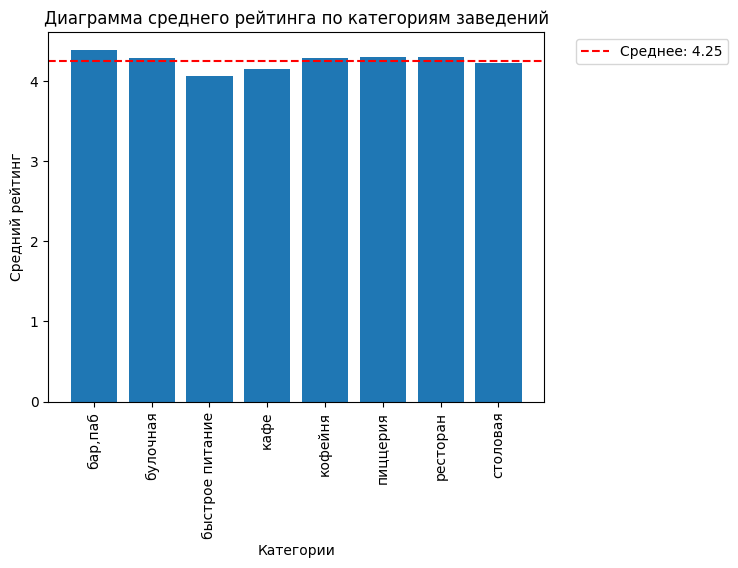

In [53]:
plt.bar(df_category_rating['category'], df_category_rating['среднее'])

plt.axhline(
    df_category_rating['среднее'].mean(),
    color='red',
    linestyle='--',
    label=f'Среднее: {df_category_rating['среднее'].mean():.2f}'
)

# Настраиваем оформление графика
plt.title('Диаграмма среднего рейтинга по категориям заведений')  
plt.xlabel('Категории')                
plt.ylabel('Средний рейтинг')  
plt.xticks(rotation=90)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

### 3.6 Иследование корреляции данных

In [ ]:
# Вычисляем корреляционную матрицу
df_corr = df[['category', 'district', 'rating', 'chain', 'seats', 'price', 'is_24_7']].phik_matrix()

df_corr[df_corr.index != 'rating']['rating'].sort_values()

interval columns not set, guessing: ['rating', 'chain', 'seats']


seats       0.000000
chain       0.114583
is_24_7     0.174699
category    0.178608
district    0.197004
price       0.220942
Name: rating, dtype: float64

### 3.7 Ретинг топ-15

In [ ]:
# Выводим топ-15 сетевых организаций по количеству заведений
df.groupby('name')['id'].count().sort_values(ascending=False).head(15)

name
Шоколадница                            120
Кафе                                   101
Домино'с Пицца                          76
Додо Пицца                              74
One Price Coffee                        71
Яндекс Лавка                            68
Cofix                                   65
Prime                                   50
КОФЕПОРТ                                42
Хинкальная                              39
Кулинарная лавка братьев Караваевых     39
Теремок                                 38
Шаурма                                  33
CofeFest                                32
Буханка                                 31
Name: id, dtype: int64

### 3.8 Иследование среднего чека заведений

In [ ]:
# Заменяем в солбце middle_avg_bill значения 0 на None 
df['middle_avg_bill'] = df['middle_avg_bill'].apply(lambda x: x if x > 0 else None)

# Фильтруем данные с ненулевым значением middle_avg_bill
df_middle_avg_bill = df[df['middle_avg_bill'].notna()]

# Создадим столбец индикатор расположено ли заведение в ЦАО
df_middle_avg_bill['in_cad'] = df_middle_avg_bill['district'].str.startswith('Центральный', na=False).astype('int')


In [41]:
# Выводим данные описательной статистики по районам
df_middle_avg_bill.groupby('district')['middle_avg_bill'].describe().round(2) 

,count,mean,std,min,25%,50%,75%,max
district,,,,,,,,
Восточный административный округ,260.0,820.63,850.90,50.0,338.00,575.0,1100.0,10000.0
Западный административный округ,305.0,1053.07,780.28,50.0,425.00,1000.0,1500.0,5250.0
Северный административный округ,322.0,927.96,912.61,130.0,350.00,650.0,1250.0,11000.0
Северо-Восточный административный округ,301.0,716.61,591.23,50.0,325.00,500.0,950.0,4500.0
Северо-Западный административный округ,157.0,822.22,595.06,120.0,340.00,700.0,1100.0,2900.0
Центральный административный округ,1056.0,1191.69,920.86,67.0,500.00,1000.0,1500.0,7250.0
Юго-Восточный административный округ,194.0,654.10,566.83,30.0,281.25,450.0,887.5,3750.0
Юго-Западный административный округ,235.0,792.56,559.17,100.0,350.00,600.0,1100.0,2750.0
Южный административный округ,312.0,836.30,2014.88,100.0,350.00,500.0,1062.5,35000.0


In [42]:
# Выводим данные описательной статистики по ЦАО и остальных районов
cad_stats = df_middle_avg_bill.groupby('in_cad')['middle_avg_bill'].describe().round(2)
cad_stats.index = ['Другие округа', 'ЦАО']
cad_stats

,count,mean,std,min,25%,50%,75%,max
Другие округа,2086.0,839.99,1033.29,30.0,350.0,600.0,1150.0,35000.0
ЦАО,1056.0,1191.69,920.86,67.0,500.0,1000.0,1500.0,7250.0


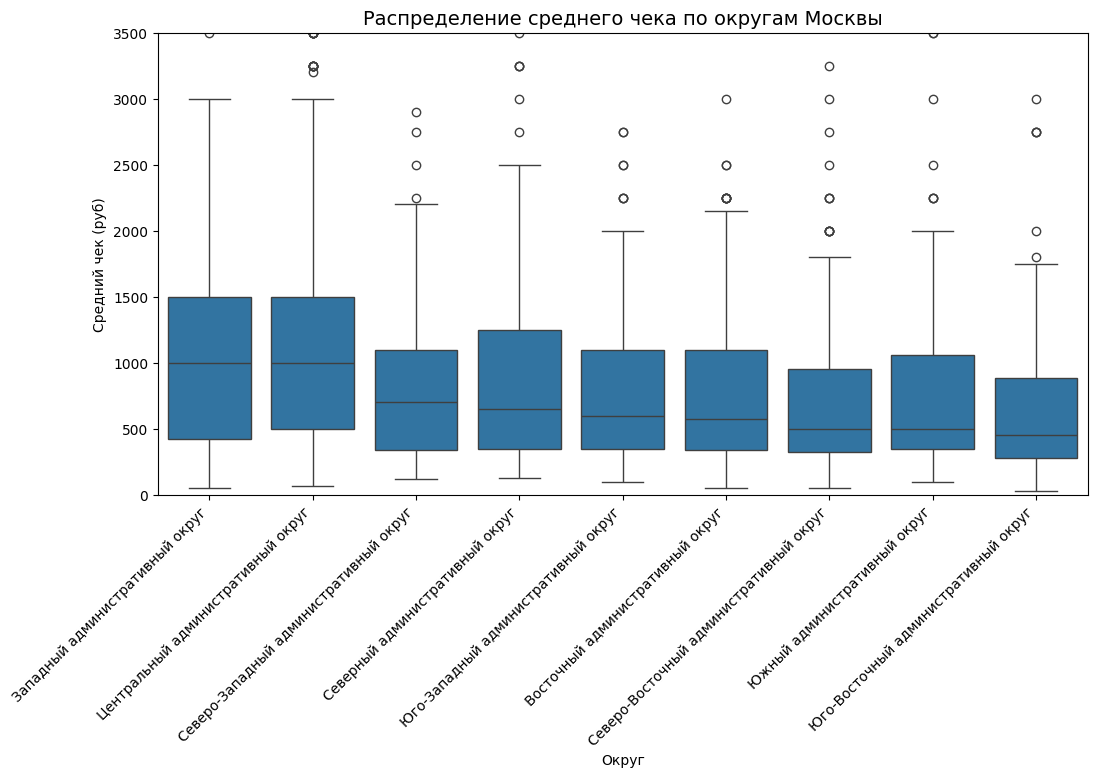

In [43]:
# Создаем график
plt.figure(figsize=(12, 6))

# Сортируем округа по убыванию среднего чека
order = df_middle_avg_bill.groupby('district')['middle_avg_bill'].median().sort_values(ascending=False).index

# Рисуем box plot
sns.boxplot(data=df_middle_avg_bill, 
            x='district', 
            y='middle_avg_bill', 
            order=order)

# Настраиваем внешний вид
plt.xticks(rotation=45, ha='right')
plt.title('Распределение среднего чека по округам Москвы', fontsize=14)
plt.xlabel('Округ')
plt.ylabel('Средний чек (руб)')
plt.ylim(0, 3500)  # Убираем выбросы для наглядности

plt.show()

C:\Users\meyak\AppData\Local\Temp\ipykernel_15660\2301991022.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box_plot = plt.boxplot([other_data, center_data],


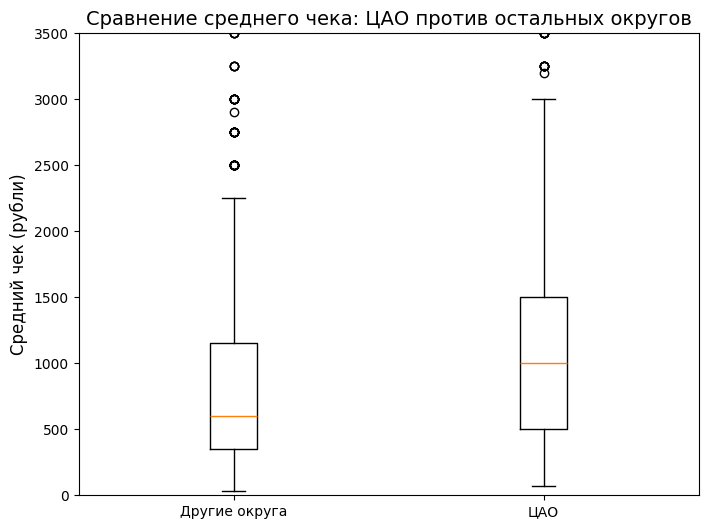

In [44]:
# Добавляем категорию расположения (1 - ЦАО, 0 - все остальные)
df_middle_avg_bill['in_center'] = (df_middle_avg_bill['district'] == 'Центральный административный округ').astype(int)

# Отделяем данные центра и других округов
center_data = df_middle_avg_bill[df_middle_avg_bill['in_center'] == 1]['middle_avg_bill']
other_data = df_middle_avg_bill[df_middle_avg_bill['in_center'] == 0]['middle_avg_bill']

# Создаем график
plt.figure(figsize=(8, 6))

# Рисуем box plot
box_plot = plt.boxplot([other_data, center_data], 
                       labels=['Другие округа', 'ЦАО'])

# Настройка графика
plt.title('Сравнение среднего чека: ЦАО против остальных округов', fontsize=14)
plt.ylabel('Средний чек (рубли)', fontsize=12)
plt.ylim(0, 3500)

plt.show()

## 4. Итоговый вывод и рекомендации <a id=4></a>